<a href="https://colab.research.google.com/github/00015775/learning-lab/blob/learn%2Fpytorch/pytorch/notebooks/01_youtube_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Workflow

In [1]:
%pip list --format=freeze # default installed packages

absl-py==1.4.0
accelerate==1.12.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.1
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
apsw==3.51.2.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.1.12.0.42.13
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.6
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.31.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.1.0
blosc2==3.12.2
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.4
catalogue==2.0.10
certifi==2026.1.4
c

In [2]:
!python --version

Python 3.12.12


In [3]:
%cat /etc/os-release

PRETTY_NAME="Ubuntu 22.04.5 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.5 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy


In [4]:
import torch
from torch import nn # model training building block
import torch.nn.functional as F
import numpy as np
import sys
import matplotlib.pyplot as plt

print(torch.__version__)
print(sys.version)

2.9.0+cpu
3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [5]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cpu')

In [6]:
%pwd

'/content'

**Youtube Video:** https://www.youtube.com/watch?v=Z_ikDlimN6A

## 1.

**Weighted Sum:**\
$z = \sum_{i=1}^{n} x_i w_i + b$
     

- Dot Product and Matrix Multiplication are not commutative, meaning that for matrices A and B, the product A•B is usually not the same as B•A (A•B $\not=$ B•A), even when both products exist.

- Key points are that the _order matters_, the **dimensions must align** (columns of first = rows of second), and unlike regular numbers, you can have AB = 0 even if A $\not=$ 0 and B $\not=$ 0.

- For more examples visit: https://math.stackexchange.com/a/3851396



In [7]:
%time # how long it took to execute a given cell
X = torch.rand(size=(5,4))
w = torch.rand_like(X)

#b = np.arange(0,4, dtype=np.long).reshape(4,1)
b = torch.arange(0, 4, dtype=torch.long).reshape(4,1)

print("\nX:", X.shape, X.dtype)
print("w:", w.shape, w.dtype)
print("b:", b.shape, b.dtype, "\n")

# w.T @ X, result in shape of (4,4), and b is (4,1), so y must have shape of (4,4)
y = torch.matmul(w.T, X) + b
print("y:", y.shape, y.dtype, "\n\n")

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 8.58 µs

X: torch.Size([5, 4]) torch.float32
w: torch.Size([5, 4]) torch.float32
b: torch.Size([4, 1]) torch.int64 

y: torch.Size([4, 4]) torch.float32 




In [8]:
a = torch.tensor(5)
b = np.ndarray(4, dtype=np.float32)
c = a + b
type(a), a.dtype, type(b), b.dtype, type(c), c.dtype

/tmp/ipython-input-267345733.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  c = a + b


(torch.Tensor,
 torch.int64,
 numpy.ndarray,
 dtype('float32'),
 torch.Tensor,
 torch.float64)

In [9]:
# creating a dummy example

weight = 0.7 # will be random, importance of each input feature
bias = 0.3 # allows going up and down on y-axis


start = 0
end = 1
step = 0.02

# small letter represent row or column vector and scalar
# capital letters represent matrix and tensor
# even though it is vector not, we will turn it into tensor on later stages
X = torch.arange(start, end, step).unsqueeze(dim=1) # turns [50] to [50, 1]
y = weight * X + bias # y_true

print("shapes:", X.shape, y.shape)
print("lengths:", len(X), len(y))
print("X:", X[:10], "\n\ny:", y[:10])

shapes: torch.Size([50, 1]) torch.Size([50, 1])
lengths: 50 50
X: tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]]) 

y: tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])


In [10]:
# X == X[:,:] # and X == X[:] are equal

In [11]:
X[:10].shape # [row, column]

torch.Size([10, 1])

### Splitting data into training, validation and test sets is important

In [12]:
X.shape, y.shape

(torch.Size([50, 1]), torch.Size([50, 1]))

In [13]:
# creating train/test split

train_split = int(0.8 * len(X))
print(train_split)

X_train, y_train = X[:train_split], y[:train_split]
print("\ntraining set:", X_train.shape, y_train.shape)

X_test, y_test = X[train_split:], y[train_split:]
print("\ntesting set:", X_test.shape, y_test.shape)

40

training set: torch.Size([40, 1]) torch.Size([40, 1])

testing set: torch.Size([10, 1]) torch.Size([10, 1])


In [14]:
len(X_train), len(y_train)

(40, 40)

In [15]:
len(X_test), len(y_test)

(10, 10)

In [16]:
#X_train, y_train

- Well, these numbers may not be intuitive to understand, but with visualization, we can get the sence of what the dataset contains.

- It is not best practice to look at the raw dataset, and expect yourself to understand it, but rather use aggeragation to extract high-level overview of the dataset.

In [17]:
# Visualizing dataset
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None
                     ):
  """
  Plots training data, test data and compared predictions
  """
  plt.figure(figsize=(10,7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot testing data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend, allows showing labels
  plt.legend(prop={"size": 14})

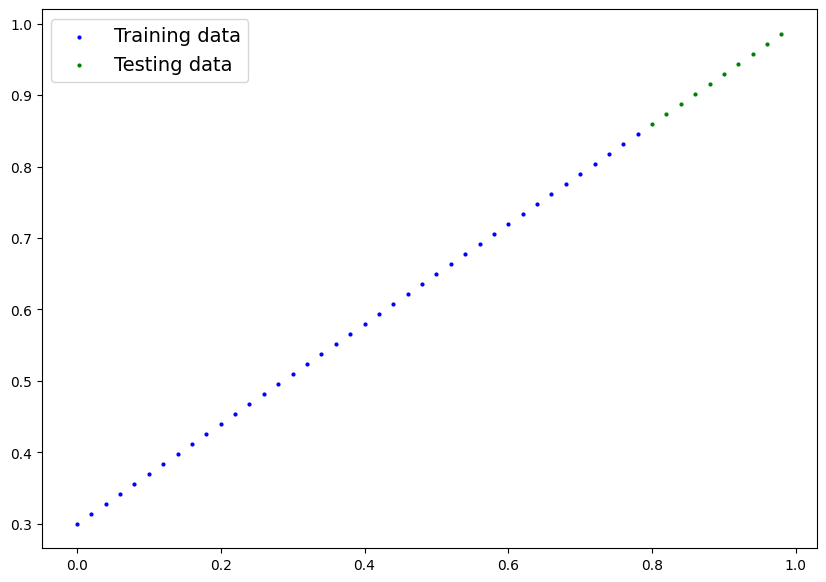

In [18]:
# it shows, the linear relationship between input features and target labels
# but in reality, relationship of X and y are rarely linear
plot_predictions()

# visualize, visualize, visualize

## Building model

In [19]:
import torch.nn as nn
import torch.nn.functional as F

class Model(nn.Module):
    def __init__(self):
        super().__init__()  # must define first and then other variables
        self.conv1 = nn.Conv2d(1, 20, 5)
        self.conv2 = nn.Conv2d(20, 20, 5)

    def forward(self, x):   # defines the flow of the data
        x = F.relu(self.conv1(x))
        return F.relu(self.conv2(x))

In [20]:
import torch
import torch.nn as nn

class MyLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(MyLinear, self).__init__()
        # Define weight and bias parameters
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.bias = nn.Parameter(torch.randn(out_features))

    def forward(self, x):
        # Implement the forward pass
        return torch.matmul(x, self.weight.t()) + self.bias

model = MyLinear(5,5)

for name, value in model.named_parameters():
  print("\n", name, value, value.shape)


 weight Parameter containing:
tensor([[-0.2863,  0.3658, -0.1999,  0.5013,  1.1292],
        [-1.3539,  0.3511, -0.4749, -0.9107, -0.8961],
        [-0.4097,  0.5121, -0.6678,  1.3400, -1.2747],
        [-0.6588,  1.2968,  0.1910,  0.5134,  1.6564],
        [-0.8345,  1.5797,  0.4120, -1.4566, -0.5159]], requires_grad=True) torch.Size([5, 5])

 bias Parameter containing:
tensor([0.2286, 1.5766, 0.4935, 0.7289, 1.2586], requires_grad=True) torch.Size([5])


In the example above, `self.weight` and `self.bias` are instances of `torch.nn.Parameter`.
During training, these parameters will be updated to minimize the loss function,
thanks to their registration as module parameters.


**Why Use `torch.nn.Parameter`?**

Using `torch.nn.Parameter` offers several advantages:   

- **Explicitness**: It makes it clear which tensors are intended to be parameters that the optimizer should update, improving code readability and maintainability.

- **Convenience**: It simplifies the implementation of custom layers and models, as PyTorch handles the underlying complexity of parameter updates.

- **Compatibility**: Ensures compatibility with various PyTorch functionalities like optimizers, saving, and loading mechanisms.

Source:
- https://www.geeksforgeeks.org/deep-learning/understanding-torchnnparameter/
- https://apxml.com/courses/getting-started-with-pytorch/chapter-4-building-models-torch-nn/torch-nn-module-base-class

**Linear Regression:**\
$z = x_i w_i + b$

_Example:_
$ {Unit.Sales_t} = \alpha + \beta_{1} Date_{t} + \beta_{2}  Cable.TV_{t} + \beta_{3}  Int.Display_{t} + \beta_{4}  Local.Radio_{t} + \beta_{5}  Magazines_{t} + \beta_{6}  Network.TV_{t} + \beta_{7}  Spot.TV_{t} + \epsilon$

Source: https://tex.stackexchange.com/questions/218599/multiline-regression-equation-in-latex
<br>

**Remember:**  
They are not the same, but related!
- $z = \sum_{i=1}^{n} x_i w_i + b$
- $z = x_i w_i + b$



In [21]:
# Create linear regression model class
class LinearRegressionModel(nn.Module): # almost everything in PyTorch inherts from nn.Module
  def __init__(self):  # contructor
    super().__init__()
    # initializing model parameters
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                        requires_grad=True,
                                        dtype=torch.float)) # torch.float is float32

  def forward(self, x: torch.Tensor) -> torch.Tensor: # -> means it must/will return anything of type torch.Tensor
    return self.weights * x + self.bias # linear regression, and NOT weighted sum

- `torch.nn.Parameter` objects have `requires_grad` set to `True` by default, so explicitly specifying `requires_grad=True` is not necessary.

- The primary purpose of wrapping a `torch.Tensor` in a `torch.nn.Parameter` is to register it as a parameter of a `torch.nn.Module`, making it discoverable by the module's `parameters()` method and thus included in the optimizer's calculations during training.

- The default behavior aligns with this purpose, as parameters in a neural network are typically intended to be trained (such as, require gradients).

Source: https://discuss.pytorch.org/t/do-i-need-to-have-requires-grad-true-for-input-when-switch-from-pytorch-0-3-to-1-0/39543 (_opens faster with vpn-enabled_)

### Checking contents of PyTorch model

**Essential `nn.Module` Functionality**

Beyond defining structure and managing parameters, `nn.Module` provides several useful methods inherited by your custom classes:

<br>

- `parameters()`: Returns an iterator over all `nn.Parameter` objects within the module (including those in submodules). This is typically used to provide the model's parameters to an optimizer.

<br>

- `named_parameters()`: Similar to `parameters()`, but yields tuples of (parameter name, parameter object). Useful for inspecting or selectively modifying specific parameters.

<br>

- `children()`: Returns an iterator over the immediate child modules (submodules defined as attributes).

<br>

- `modules()`: Returns an iterator over all modules within the network, starting with the module itself and then recursively iterating through all submodules.

<br>

- `state_dict()`: Returns a Python dictionary containing the entire state of the module, primarily mapping each parameter and buffer name to its corresponding tensor. This is fundamental for saving model weights.

<br>

- `load_state_dict()`: Loads a state (usually from a saved file) back into the module, restoring parameters and buffers.

<br>

- `to(device)`: Moves all the module's parameters and buffers to the specified device (e.g., '`cuda`' for GPU or '`cpu`', '`mps`' for MacOS M-series GPU). This is important for hardware acceleration.

<br>

- `train()`: Sets the module and its submodules to training mode. This affects layers like `Dropout` and `BatchNorm`, which behave differently during training and evaluation.

<br>

- `eval()`: Sets the module and its submodules to evaluation mode.

<br>

Source: https://apxml.com/courses/getting-started-with-pytorch/chapter-4-building-models-torch-nn/torch-nn-module-base-class

In [22]:
# Create linear regression model class
class LinearRegressionModel(nn.Module): # almost everything in PyTorch inherts from nn.Module
  def __init__(self):  # contructor
    super().__init__()
    # initializing model parameters
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                        requires_grad=True,
                                        dtype=torch.float)) # torch.float is float32

  def forward(self, x: torch.Tensor) -> torch.Tensor: # -> means it must/will return anything of type torch.Tensor
    return self.weights * x + self.bias # linear regression, and NOT weighted sum

In [23]:
torch.randn(1) # different each time

tensor([0.5436])

In [24]:
torch.manual_seed(42)
torch.randn(1) # now the same each time

tensor([0.3367])

In [25]:
# create random seed
torch.manual_seed(42)

# create instance of the model
model_0 = LinearRegressionModel()

# checking out parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [26]:
for name, value in model_0.named_parameters():
  print("\n", name, value)


 weights Parameter containing:
tensor([0.3367], requires_grad=True)

 bias Parameter containing:
tensor([0.1288], requires_grad=True)


In [27]:
model_0.state_dict() # {parameter_name: tensor_value}

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [28]:
weight, bias # intended approximate target value for weight and bias

(0.7, 0.3)

### Making predictions using `torch.inference_mode()`

- To check out model's predictive power, let's see how well it predicts `y_test` based on `X_test`.


- When we pass data through our model, it's going to run it through a `forward()` method.

In [29]:
X_test, X_test.shape

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 torch.Size([10, 1]))

In [30]:
# if we do this way, gradients are calculated, hence uses up resources
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [31]:
# making predictions with model

# with torch.inference_mode() no gradients are calcuated, saves resources
# context manager
with torch.inference_mode(): # it is analogous to torch.no_grad(), but much better
  y_preds = model_0(X_test) # forward pass

y_preds # intention is to get as close as possible to y_test

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [32]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

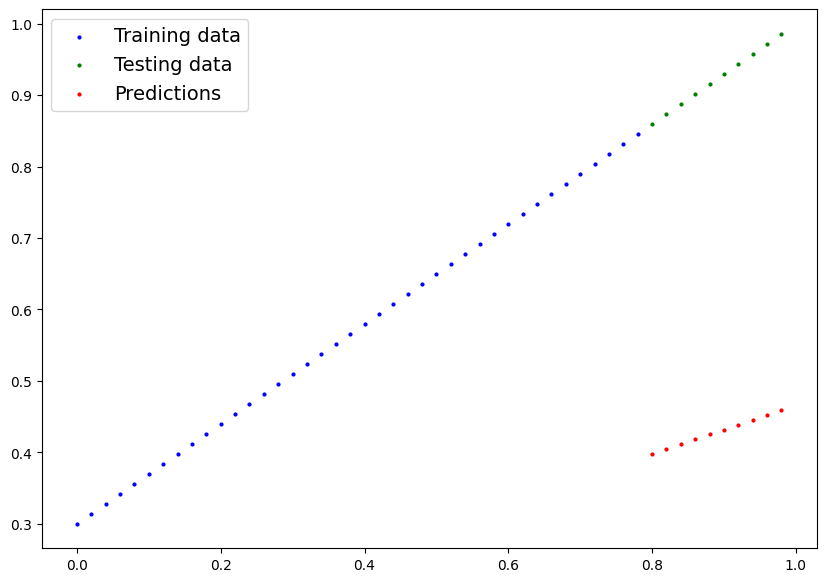

In [33]:
plot_predictions(predictions=y_preds)
# random predictions, because gradients/optim/loss are not being used to learn from data

In [34]:
# stopped at 5:40

### Train Model


The whole idea of training is for a model to move from *unknown* parameters (these may be random) to some *known* parameters.

In other, words from a poor representation of the data to a better representation of the data.

One way to measure how poor or how wrong models predictions are, is to use loss function (also called `criterion`, or cost function or objective function).

Things we need to train:

- **Loss function:** a function to measure how wrong models' predictions are.

-  **Optimizer:** Takes into account the loss of a model and adjusts the models' parameters (`weights` and `biases`)

For PyTorch, we need:
- A training loop
- A testing loop


In [35]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [36]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [37]:
import torch.nn as nn
import torch.optim as optim

# Setup loss function
loss_fn = nn.L1Loss()

# Setup an optimizer
# optimizer uses the loss function results and then updates weight and biases to lower this loss
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)


In [38]:
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [39]:
model_0.eval() # turns off gradient tracking

LinearRegressionModel()

In [40]:
%time
torch.manual_seed(42)

# an epoch is looping through entire data ONCE
loss_fn = nn.L1Loss()
optimizer = optim.SGD(model_0.parameters(),
                      lr=0.01)

epochs = 100

for epoch in range(epochs):
  # set the model to training mode
  model_0.train()

  y_pred = model_0(X_train)

  loss = loss_fn(y_pred, y_train)
  print("Loss:", loss.item())

  # helps to avoid gradient accumulation and previous batch effecting the results of the current batch
  optimizer.zero_grad()

  loss.backward() # gradients for y are calculated with respect to the weights of input features

  optimizer.step()


  # evaluation and testing
  model_0.eval() # turns off setting in the model not needed for evaluation, saving resources and performance
  with torch.inference_mode(): # gradients are disabled, much better then "torch.no_grad()"
    # forward pass
    test_pred = model_0(X_test)

    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 6.91 µs
Loss: 0.31288138031959534
Epoch: 0 | Loss: 0.3129 | Test Loss: 0.4811
Loss: 0.3013603389263153
Loss: 0.28983935713768005
Loss: 0.2783183455467224
Loss: 0.26679736375808716
Loss: 0.2552763521671295
Loss: 0.24375534057617188
Loss: 0.23223432898521423
Loss: 0.22071333229541779
Loss: 0.20919232070446014
Loss: 0.1976713240146637
Epoch: 10 | Loss: 0.1977 | Test Loss: 0.3464
Loss: 0.18615034222602844
Loss: 0.1746293306350708
Loss: 0.16310831904411316
Loss: 0.1515873372554779
Loss: 0.14006635546684265
Loss: 0.1285453587770462
Loss: 0.11702437698841095
Loss: 0.1060912236571312
Loss: 0.09681284427642822
Loss: 0.08908725529909134
Epoch: 20 | Loss: 0.0891 | Test Loss: 0.2173
Loss: 0.08227583020925522
Loss: 0.07638873159885406
Loss: 0.07160007208585739
Loss: 0.06747635453939438
Loss: 0.06395438313484192
Loss: 0.06097004935145378
Loss: 0.05845819041132927
Loss: 0.05635259300470352
Loss: 0.0545857772231102
Loss: 0.053148526698350906
Epoc

In [41]:
with torch.inference_mode(): # gradients are disabled
  y_preds_new = model_0(X_test)

In [42]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [43]:
weight, bias

(0.7, 0.3)

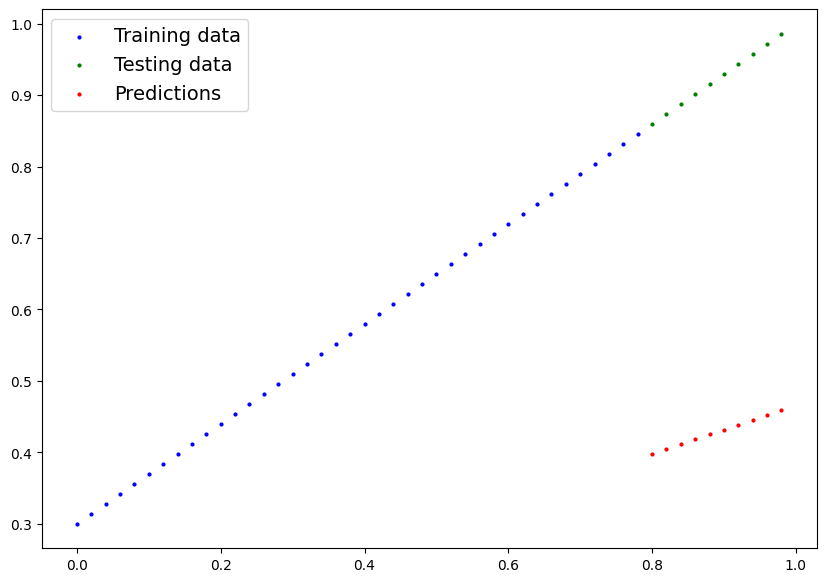

In [44]:
plot_predictions(predictions=y_preds) # before training

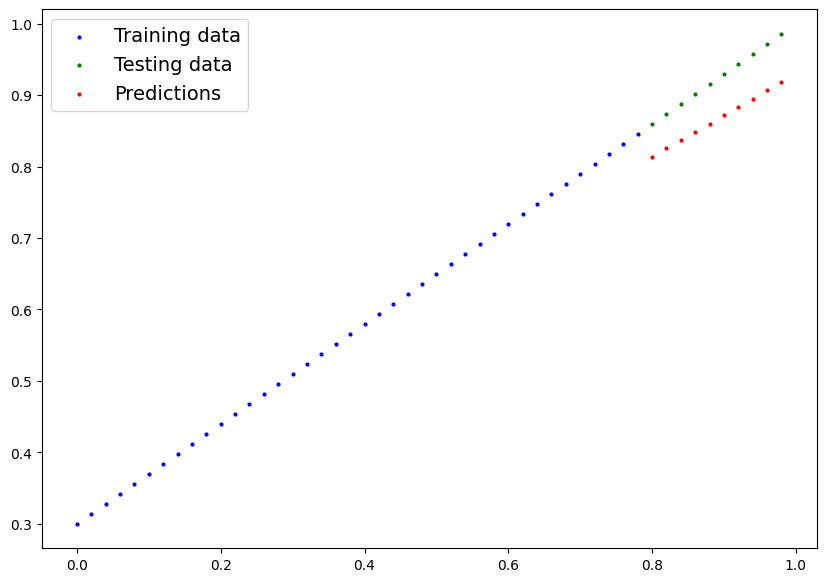

In [45]:
plot_predictions(predictions=y_preds_new) # after training

In [46]:
# Stopped at 7:00

In [47]:
dir(model_0)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_non_full_backward_hook',
 '_modules',
 '_named_members',
 '_non_persistent_buffers_se

### Visualizing the importance of activation function

In [48]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(30)
np.random.seed(30)

X_train = torch.linspace(-10, 10, steps=1000).unsqueeze(1)
y_train = X_train ** 3

X_train = X_train.to(device)
y_train = y_train.to(device)

In [49]:
X_train.shape, y_train.shape

(torch.Size([1000, 1]), torch.Size([1000, 1]))

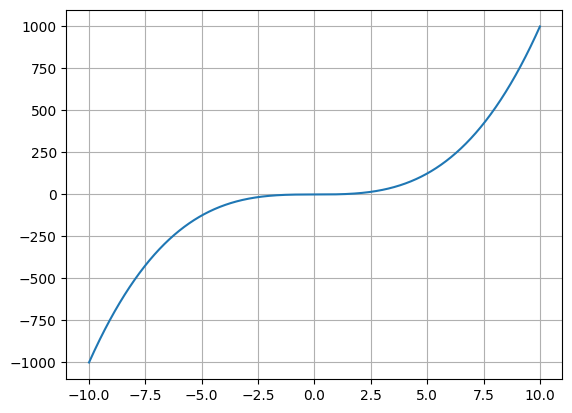

In [50]:
plt.plot(X_train, y_train)
plt.grid(True)
plt.show()

In [51]:
# without activation function
class NetNoActivation(nn.Module):
  def __init__(self):
    super(NetNoActivation, self).__init__()
    self.model = nn.Sequential(
        nn.Linear(1, 50),
        nn.Linear(50, 50),
        nn.Linear(50, 50),
        nn.Linear(50, 50),
        nn.Linear(50, 1)
    )


  def forward(self, x):
    return self.model(x)


# with activation function
class NetWithActivation(nn.Module):
  def __init__(self):
    super(NetWithActivation, self).__init__()
    self.model = nn.Sequential(
        nn.Linear(1, 50),
        nn.ReLU(),
        nn.Linear(50, 50),
        nn.ReLU(),
        nn.Linear(50, 50),
        nn.ReLU(),
        nn.Linear(50, 50),
        nn.ReLU(),
        nn.Linear(50, 1),
    )

  def forward(self, x):
    return self.model(x)

In [52]:
def train_model(model, inputs, targets, epochs=1000, lr=0.001):
  losses = []
  model = model.to(device)
  criterion = nn.MSELoss()
  optimizer = optim.Adam(model.parameters(),
                         lr=lr)

  model.train()
  for epoch in range(epochs):
    optimizer.zero_grad()

    outputs = model(inputs)
    loss = criterion(outputs, targets)
    losses.append(loss.item())
    loss.backward()

    optimizer.step()

  if epoch % 100 == 0:
    print(f"Epoch [{epoch}/{epochs}] | Loss {loss.item()}")

  return model, losses

In [53]:
def plot_results(model, inputs, targets, title: str, losses):
  model.eval()
  with torch.inference_mode():
    x_plot = inputs.to(device)
    y_plot = x_plot ** 3
    y_pred = model(x_plot)


  x_plot = x_plot.cpu().numpy()
  y_plot = y_plot.cpu().numpy()
  y_pred = y_pred.cpu().numpy()

  plt.plot(x_plot, y_plot, c="g", label="True X^3")
  plt.plot(x_plot, y_pred, c="r", label="Model Prediction")
  plt.title(title)
  plt.xlabel("x")
  plt.ylabel("y")
  plt.legend()
  plt.grid(True)
  plt.show



In [54]:
X_train.dtype, y_train.dtype, X_train.shape, y_train.shape

(torch.float32, torch.float32, torch.Size([1000, 1]), torch.Size([1000, 1]))

Training ANN without activation function...


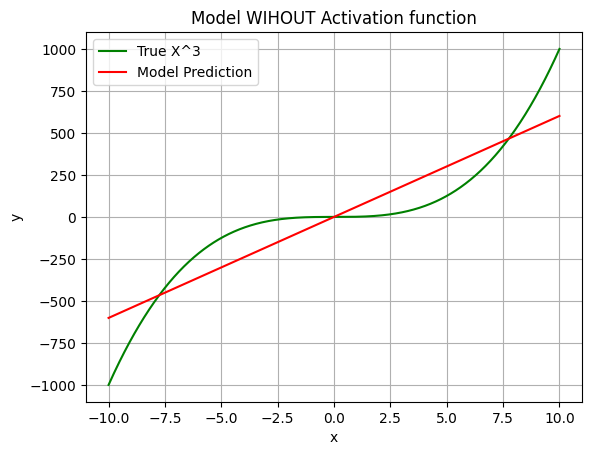

In [55]:
# train and plot results

print("Training ANN without activation function...")
model_no_act = NetNoActivation()
model_no_act, losses_no_ac = train_model(model=model_no_act, inputs=X_train, targets=y_train, epochs=1000, lr=0.001)
plot_results(model_no_act, X_train, y_train, "Model WIHOUT Activation function", losses_no_ac)


Training ANN with activation function...


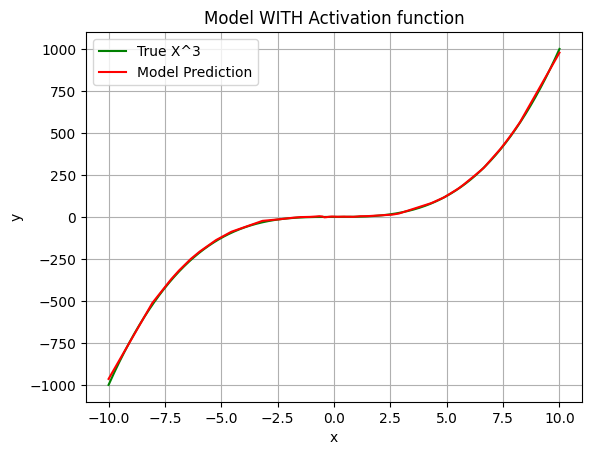

In [56]:
print("\nTraining ANN with activation function...")
model_with_act = NetWithActivation()
model_with_act, losses_with_ac = train_model(model=model_with_act, inputs=X_train, targets=y_train, epochs=1000, lr=0.001)
plot_results(model_with_act, X_train, y_train, "Model WITH Activation function", losses_with_ac)

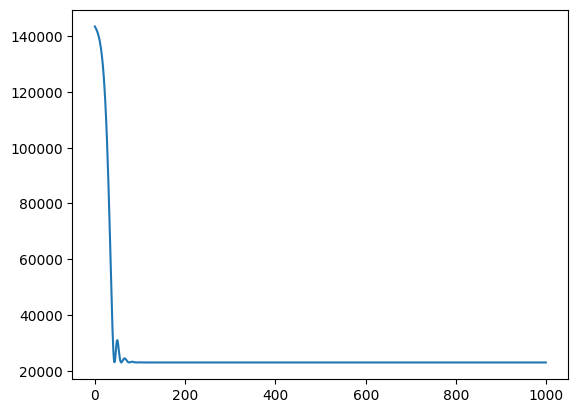


len=1000 | min=22994.443359375 | max=143462.140625


In [57]:
plt.plot(losses_no_ac, label="Without Activation")
plt.show()

print(f"\nlen={len(losses_no_ac)} | min={min(losses_no_ac)} | max={max(losses_no_ac)}")

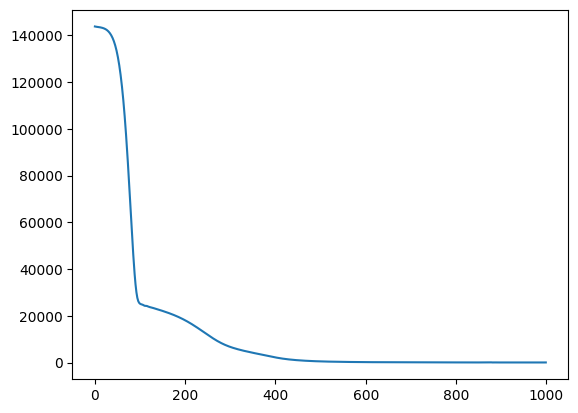


len=1000 | min=21.817981719970703 | max=143782.046875


In [58]:
plt.plot(losses_with_ac, label="With Activation")
plt.show()

print(f"\nlen={len(losses_with_ac)} | min={min(losses_with_ac)} | max={max(losses_with_ac)}")

In [59]:
%time
torch.manual_seed(42)

# an epoch is looping through entire data ONCE
loss_fn = nn.L1Loss()
optimizer = optim.SGD(model_0.parameters(),
                      lr=0.01)

epochs = 200

epoch_count = []
loss_values = []
test_loss_values = []


for epoch in range(epochs):
  epoch_count.append(epoch)
  # set the model to training mode
  model_0.train()

  y_pred = model_0(X_train)

  loss = loss_fn(y_pred, y_train)
  print("Loss:", loss.item())
  loss_values.append(loss.item())

  # helps to avoid gradient accumulation and previous batch effecting the results of the current batch
  optimizer.zero_grad()

  loss.backward() # gradients for y are calculated with respect to the weights of input features

  optimizer.step()


  # evaluation and testing
  model_0.eval() # turns off setting in the model not needed for evaluation, saving resources and performance
  with torch.inference_mode(): # gradients are disabled, much better then "torch.no_grad()"
    # forward pass
    test_pred = model_0(X_test)

    test_loss = loss_fn(test_pred, y_test)
    test_loss_values.append(test_loss.item())

  if epoch % 20 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 5.01 µs
Loss: 247.89501953125
Epoch: 0 | Loss: 247.8950 | Test Loss: 0.0137
Loss: 247.6491241455078
Loss: 247.4033966064453
Loss: 247.1580047607422
Loss: 246.91278076171875
Loss: 246.6677703857422
Loss: 246.42294311523438
Loss: 246.17835998535156
Loss: 245.93443298339844
Loss: 245.6918487548828
Loss: 245.4500274658203
Loss: 245.2089080810547
Loss: 244.96841430664062
Loss: 244.7285919189453
Loss: 244.48931884765625
Loss: 244.25067138671875
Loss: 244.01254272460938
Loss: 243.77499389648438
Loss: 243.53799438476562
Loss: 243.3015594482422
Loss: 243.06556701660156
Epoch: 20 | Loss: 243.0656 | Test Loss: 0.8450
Loss: 242.83001708984375
Loss: 242.59495544433594
Loss: 242.36053466796875
Loss: 242.12660217285156
Loss: 241.89303588867188
Loss: 241.66001892089844
Loss: 241.427490234375
Loss: 241.19541931152344
Loss: 240.96389770507812
Loss: 240.73275756835938
Loss: 240.5021209716797
Loss: 240.27198791503906
Loss: 240.0423583984375
Loss: 239

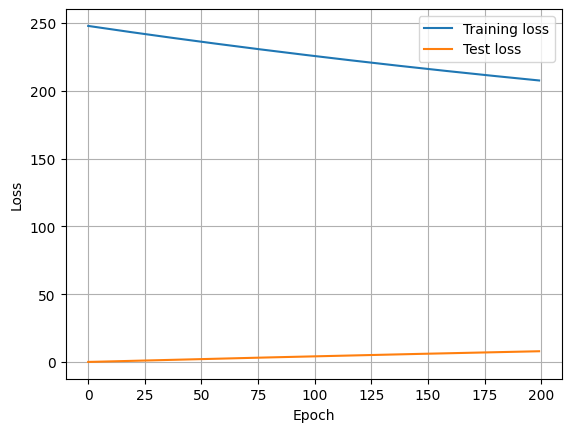

In [60]:
plt.plot(epoch_count, loss_values, label="Training loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [61]:
model_0.state_dict()

OrderedDict([('weights', tensor([9.5545])), ('bias', tensor([0.3096]))])

In [62]:
print(model_0)

LinearRegressionModel()


### Saving a model in PyTorch

There are three main methods to save the model:


1. `torch.save()`: `pickle` - serializing (_saving_), deserialzing(_loading_)

2. `torch.load()`: allows a saved PyTorch object

3. `torch.nn.Module.load_state_dict()`: this allows to load a model's saved state dictionary, basically a dictionary with parameters as keys and their tensor values as values



Source: https://docs.pytorch.org/tutorials/beginner/basics/saveloadrun_tutorial.html

Source: https://www.geeksforgeeks.org/deep-learning/save-and-load-models-in-pytorch/

In [63]:
model_0.state_dict()

OrderedDict([('weights', tensor([9.5545])), ('bias', tensor([0.3096]))])

In [64]:
# stopped at 7:22

In [65]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, TensorDataset

In [66]:
# helps to convert Python PIL Image into PyTorch tensor format
# also defines the mean and std as 0.5 and 0.5 respectively, so pixel value ranges
# are [-1.0, 1.0]

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, ), (0.5, )) # it supports operations on PyTorch tensors and not PIL Images
])

In [67]:
dir(transforms) # list of all functions and attributes

['AugMix',
 'AutoAugment',
 'AutoAugmentPolicy',
 'CenterCrop',
 'ColorJitter',
 'Compose',
 'ConvertImageDtype',
 'ElasticTransform',
 'FiveCrop',
 'GaussianBlur',
 'Grayscale',
 'InterpolationMode',
 'Lambda',
 'LinearTransformation',
 'Normalize',
 'PILToTensor',
 'Pad',
 'RandAugment',
 'RandomAdjustSharpness',
 'RandomAffine',
 'RandomApply',
 'RandomAutocontrast',
 'RandomChoice',
 'RandomCrop',
 'RandomEqualize',
 'RandomErasing',
 'RandomGrayscale',
 'RandomHorizontalFlip',
 'RandomInvert',
 'RandomOrder',
 'RandomPerspective',
 'RandomPosterize',
 'RandomResizedCrop',
 'RandomRotation',
 'RandomSolarize',
 'RandomVerticalFlip',
 'Resize',
 'TenCrop',
 'ToPILImage',
 'ToTensor',
 'TrivialAugmentWide',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional_pil',
 '_functional_tensor',
 '_presets',
 'autoaugment',
 'functional',
 'transforms']

In [68]:
import time

start_download = time.time()
train_dataset = torchvision.datasets.MNIST(root="./MNIST", train=True, transform=data_transform, download=True)
test_dataset = torchvision.datasets.MNIST(root="./MNIST", train=False, transform=data_transform, download=True)
end_download = time.time() - start_download
print(f"\nDownloading took {end_download} seconds")

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

In [69]:
len(train_loader), len(test_loader)

(938, 157)

In [70]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1)

input_tensor = torch.randn(16, 3, 32, 32) # batch_size=16, in_channels=3, height=32, width=32

output_tensor = conv_layer(input_tensor)
print(output_tensor.shape)

torch.Size([16, 64, 32, 32])


In [71]:
class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    self.conv1_layer = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1) # in_channels=1 for grayscale and 3 for RGB, out_channels=16 is defining number of neurons in each conv layer
    self.conv2_layer = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
    self.relu = nn.ReLU()
    self.max_pool2d = nn.MaxPool2d(kernel_size=2, stride=2)
    self.fc1_layer = nn.Linear(32 * 7 * 7, 128)
    self.fc2_layer = nn.Linear(128, 10)


  def forward(self, inputs):
    new_input = self.relu(self.conv1_layer(inputs))
    new_input = self.max_pool2d(new_input)
    new_input = self.relu(self.conv2_layer(new_input))
    new_input = self.max_pool2d(new_input)
    new_input = new_input.view(-1, 32 * 7 * 7) # flattening the image tensor
    new_input = self.relu(self.fc1_layer(new_input))
    new_input = self.fc2_layer(new_input)
    return new_input

In [72]:
cnn_model = SimpleCNN()

In [73]:
print(cnn_model)

SimpleCNN(
  (conv1_layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2_layer): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (max_pool2d): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1_layer): Linear(in_features=1568, out_features=128, bias=True)
  (fc2_layer): Linear(in_features=128, out_features=10, bias=True)
)


In [74]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

In [75]:
import time


epochs = 5
epoch_count = []
loss_values = []
test_loss_values = []
total_batch_steps = len(train_loader)


cnn_model.train()
cnn_model.to(device)

start_time = time.time()
for epoch in range(epochs):
  for batch_id, (images, labels) in enumerate(train_loader):
    optimizer.zero_grad()
    epoch_count.append(epoch)

    images = images.to(device)
    labels = labels.to(device)

    outputs = cnn_model(images)
    loss = criterion(outputs, labels)
    loss_values.append(loss.item()) # so now saved as simply python datatypes

    loss.backward()
    optimizer.step() # random weights are updated

    cnn_model.eval()
    with torch.inference_mode():
      test_pred = cnn_model(images)
      test_loss = criterion(test_pred, labels)
      test_loss_values.append(test_loss.item())

    if (batch_id+1) % 100 == 0:
      print(f"Epoch [{epoch+1}/{epochs}] | Batch [{batch_id+1}/{total_batch_steps}] | Loss {loss.item():.4f} | Training Loss {test_loss.item():.4f} (After model updates)")

end_time = time.time() - start_time

if end_time < 60:
  print(f"Training took {end_time} seconds")
else:
  print(f"Training took {end_time//60} minutes")

Epoch [1/5] | Batch [100/938] | Loss 0.3849 | Training Loss 0.3743 (After model updates)
Epoch [1/5] | Batch [200/938] | Loss 0.3988 | Training Loss 0.3554 (After model updates)
Epoch [1/5] | Batch [300/938] | Loss 0.1337 | Training Loss 0.1311 (After model updates)
Epoch [1/5] | Batch [400/938] | Loss 0.1523 | Training Loss 0.1474 (After model updates)
Epoch [1/5] | Batch [500/938] | Loss 0.0379 | Training Loss 0.0343 (After model updates)
Epoch [1/5] | Batch [600/938] | Loss 0.0569 | Training Loss 0.0449 (After model updates)
Epoch [1/5] | Batch [700/938] | Loss 0.0637 | Training Loss 0.0579 (After model updates)
Epoch [1/5] | Batch [800/938] | Loss 0.1170 | Training Loss 0.1025 (After model updates)
Epoch [1/5] | Batch [900/938] | Loss 0.0111 | Training Loss 0.0122 (After model updates)
Epoch [2/5] | Batch [100/938] | Loss 0.0358 | Training Loss 0.0296 (After model updates)
Epoch [2/5] | Batch [200/938] | Loss 0.0504 | Training Loss 0.0434 (After model updates)
Epoch [2/5] | Batch [

In [82]:
for id, (name, tensor) in enumerate(cnn_model.named_parameters(), start=1):
  print(f"{id}. {name} = {tensor.shape}")

1. conv1_layer.weight = torch.Size([16, 1, 3, 3])
2. conv1_layer.bias = torch.Size([16])
3. conv2_layer.weight = torch.Size([32, 16, 3, 3])
4. conv2_layer.bias = torch.Size([32])
5. fc1_layer.weight = torch.Size([128, 1568])
6. fc1_layer.bias = torch.Size([128])
7. fc2_layer.weight = torch.Size([10, 128])
8. fc2_layer.bias = torch.Size([10])


In [87]:
len(epoch_count)

4690

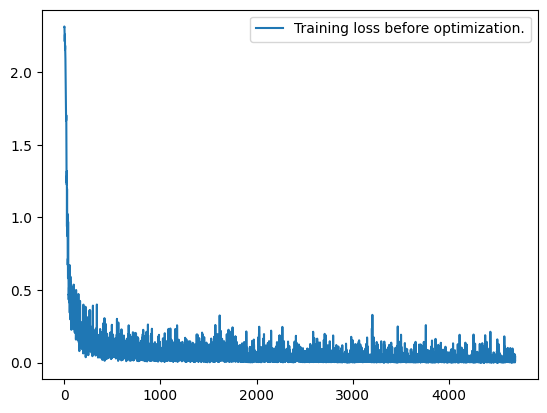

(0.00020445309928618371, 2.315443992614746)

In [95]:
plt.plot(loss_values, label="Training loss before optimization.")
plt.legend()
plt.show()

min(loss_values), max(loss_values)

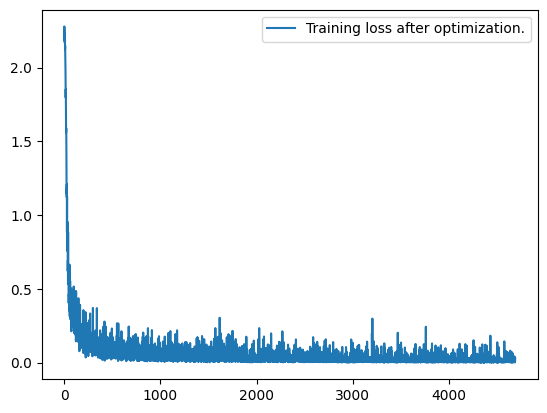

(0.0002243347407784313, 2.2793357372283936)

In [96]:
plt.plot(test_loss_values, label="Training loss after optimization.")
plt.legend()
plt.show()

min(test_loss_values), max(test_loss_values)

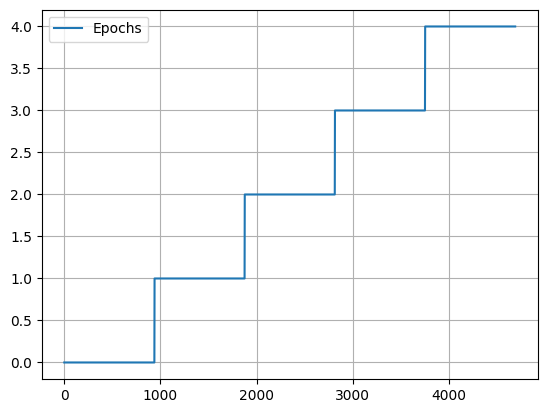

In [97]:
plt.plot(epoch_count, label="Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [112]:
correct_predictions = 0
total_samples = 0

cnn_model.to(device)
cnn_model.eval()
with torch.inference_mode():
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = cnn_model(images)
    _, predicted_labels = torch.max(outputs.data, 1)
    total_samples += labels.size(0)
    correct_predictions += (predicted_labels == labels).sum().item()

print(f"Accuracy of test set: {100 * correct_predictions / total_samples}%")

Accuracy of test set: 99.295


In [114]:
for id, (name, tensor) in enumerate(cnn_model.named_parameters(), start=1):
  print(f"{id}. {name} = {tensor.shape}")

1. conv1_layer.weight = torch.Size([16, 1, 3, 3])
2. conv1_layer.bias = torch.Size([16])
3. conv2_layer.weight = torch.Size([32, 16, 3, 3])
4. conv2_layer.bias = torch.Size([32])
5. fc1_layer.weight = torch.Size([128, 1568])
6. fc1_layer.bias = torch.Size([128])
7. fc2_layer.weight = torch.Size([10, 128])
8. fc2_layer.bias = torch.Size([10])


In [115]:
cnn_model.state_dict()

OrderedDict([('conv1_layer.weight',
              tensor([[[[ 0.2404,  0.3480, -0.1999],
                        [ 0.3267,  0.2942, -0.1407],
                        [ 0.3110,  0.2781,  0.4097]]],
              
              
                      [[[-0.4047, -0.5125, -0.0999],
                        [ 0.2103, -0.1275, -0.0703],
                        [ 0.3619,  0.4817,  0.1644]]],
              
              
                      [[[ 0.4366,  0.4252,  0.1148],
                        [ 0.2240, -0.1123, -0.3680],
                        [ 0.1466, -0.1383, -0.2931]]],
              
              
                      [[[-0.1407, -0.1014,  0.1009],
                        [ 0.3053,  0.2887, -0.2030],
                        [ 0.2211, -0.1263, -0.3133]]],
              
              
                      [[[ 0.1930,  0.3027,  0.3751],
                        [ 0.2945, -0.0298,  0.3231],
                        [-0.1747, -0.4311,  0.3327]]],
              
              
         

In [116]:
optimizer.state_dict()

{'state': {0: {'step': tensor(4690.),
   'exp_avg': tensor([[[[ 7.9133e-04,  5.2481e-04,  9.6502e-04],
             [-6.3291e-04, -2.2244e-04,  9.5915e-05],
             [-1.9637e-03, -1.8735e-03, -1.3665e-03]]],
   
   
           [[[ 1.7755e-03,  3.0918e-03,  6.1495e-04],
             [ 1.8872e-03,  3.0590e-03,  5.9131e-04],
             [ 4.2193e-03,  1.9346e-03, -1.1254e-03]]],
   
   
           [[[-5.7233e-04, -2.2586e-03, -2.7119e-03],
             [-1.5355e-03, -2.7541e-03, -2.9450e-03],
             [-1.7514e-03, -2.3577e-03, -1.0379e-03]]],
   
   
           [[[ 1.2305e-03,  5.5078e-04, -2.5588e-04],
             [ 6.4099e-04,  9.8926e-05, -8.6610e-04],
             [-6.4723e-04, -8.4444e-04, -1.2237e-03]]],
   
   
           [[[-2.7337e-03, -1.6332e-03,  6.6262e-04],
             [-3.5575e-03, -2.1823e-03, -4.4506e-04],
             [-2.1224e-03, -6.4959e-04,  3.5897e-05]]],
   
   
           [[[ 4.2197e-03,  2.2411e-03,  5.8342e-04],
             [ 1.1459e-03, -1.5187e-0

### First method of saving and loading model

In [122]:
from pathlib import Path

METHOD_ONE_SAVE_DIR = Path("./first_method")
METHOD_ONE_SAVE_DIR.mkdir(parents=True, exist_ok=True)

torch.save(cnn_model.state_dict(), "./first_method/cnn_model.pth")

In [123]:
!du -h ./first_method

816K	./first_method


In [125]:
# now need to create an instance of the same model Class in order to be able to load the parameters

loaded_model = SimpleCNN()
loaded_model.load_state_dict(torch.load("./first_method/cnn_model.pth"))

loaded_model.eval()

SimpleCNN(
  (conv1_layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2_layer): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (max_pool2d): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1_layer): Linear(in_features=1568, out_features=128, bias=True)
  (fc2_layer): Linear(in_features=128, out_features=10, bias=True)
)

In [126]:
%time
correct_predictions = 0
total_samples = 0

loaded_model.to(device)
loaded_model.eval()
with torch.inference_mode():
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = loaded_model(images)
    _, predicted_labels = torch.max(outputs.data, 1)
    total_samples += labels.size(0)
    correct_predictions += (predicted_labels == labels).sum().item()

print(f"Accuracy of test set: {100 * correct_predictions / total_samples}%")

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 7.39 µs
Accuracy of test set: 99.295%


### Second method of saving model

In [133]:
checkpoints = {
    "epochs": epochs,
    "model_state_dict": cnn_model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "training loss": loss_values,
    "testing loss": test_loss_values,
    "lr": 0.0001
}

In [134]:
len(checkpoints) # five key=pair values

6

In [135]:
from pathlib import Path

METHOD_TWO_SAVE_WITH_CHECKPOINTS = Path("./second_method_checkpoints")
METHOD_TWO_SAVE_WITH_CHECKPOINTS.mkdir(parents=True, exist_ok=True)

torch.save(checkpoints, "./second_method_checkpoints/checkpoints.pth")

In [136]:
!du -h ./second_method_checkpoints

2.5M	./second_method_checkpoints


In [137]:
checkpoints = torch.load("./second_method_checkpoints/checkpoints.pth")

checkpoints_loaded_model = SimpleCNN()
checkpoints_loaded_optimizer = optim.Adam(checkpoints_loaded_model.parameters(),
                                          lr=checkpoints["lr"])


checkpoints_loaded_model.load_state_dict(checkpoints["model_state_dict"])
checkpoints_loaded_optimizer.load_state_dict(checkpoints["optimizer_state_dict"])

In [138]:
%time
correct_predictions = 0
total_samples = 0

checkpoints_loaded_model.to(device)
checkpoints_loaded_model.eval()

with torch.inference_mode():
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = checkpoints_loaded_model(images)
    _, predicted_labels = torch.max(outputs.data, 1)
    total_samples += labels.size(0)
    correct_predictions += (predicted_labels == labels).sum().item()

print(f"Accuracy of test set: {100 * correct_predictions / total_samples}%")

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.01 µs
Accuracy of test set: 99.295%


In [147]:
for param_tensor in cnn_model.state_dict():
  print(param_tensor, "\t", cnn_model.state_dict()[param_tensor].shape)

conv1_layer.weight 	 torch.Size([16, 1, 3, 3])
conv1_layer.bias 	 torch.Size([16])
conv2_layer.weight 	 torch.Size([32, 16, 3, 3])
conv2_layer.bias 	 torch.Size([32])
fc1_layer.weight 	 torch.Size([128, 1568])
fc1_layer.bias 	 torch.Size([128])
fc2_layer.weight 	 torch.Size([10, 128])
fc2_layer.bias 	 torch.Size([10])


In [148]:
for id, (name, tensor) in enumerate(cnn_model.named_parameters(), start=1):
  print(f"{id}. {name} = {tensor.shape}")

1. conv1_layer.weight = torch.Size([16, 1, 3, 3])
2. conv1_layer.bias = torch.Size([16])
3. conv2_layer.weight = torch.Size([32, 16, 3, 3])
4. conv2_layer.bias = torch.Size([32])
5. fc1_layer.weight = torch.Size([128, 1568])
6. fc1_layer.bias = torch.Size([128])
7. fc2_layer.weight = torch.Size([10, 128])
8. fc2_layer.bias = torch.Size([10])


In [162]:
for var_name in optimizer.state_dict():
  print(var_name, "\t", optimizer.state_dict()[var_name], "\n\n")

state 	 {0: {'step': tensor(4690.), 'exp_avg': tensor([[[[ 7.9133e-04,  5.2481e-04,  9.6502e-04],
          [-6.3291e-04, -2.2244e-04,  9.5915e-05],
          [-1.9637e-03, -1.8735e-03, -1.3665e-03]]],


        [[[ 1.7755e-03,  3.0918e-03,  6.1495e-04],
          [ 1.8872e-03,  3.0590e-03,  5.9131e-04],
          [ 4.2193e-03,  1.9346e-03, -1.1254e-03]]],


        [[[-5.7233e-04, -2.2586e-03, -2.7119e-03],
          [-1.5355e-03, -2.7541e-03, -2.9450e-03],
          [-1.7514e-03, -2.3577e-03, -1.0379e-03]]],


        [[[ 1.2305e-03,  5.5078e-04, -2.5588e-04],
          [ 6.4099e-04,  9.8926e-05, -8.6610e-04],
          [-6.4723e-04, -8.4444e-04, -1.2237e-03]]],


        [[[-2.7337e-03, -1.6332e-03,  6.6262e-04],
          [-3.5575e-03, -2.1823e-03, -4.4506e-04],
          [-2.1224e-03, -6.4959e-04,  3.5897e-05]]],


        [[[ 4.2197e-03,  2.2411e-03,  5.8342e-04],
          [ 1.1459e-03, -1.5187e-04, -2.5236e-05],
          [-4.7246e-04, -3.5483e-03, -4.1106e-03]]],


        [[[

In [161]:
for var_name in optimizer.state_dict():
  print(var_name, "\t", type(optimizer.state_dict()[var_name]), "\n\n")

state 	 <class 'dict'> 


param_groups 	 <class 'list'> 




In [166]:
optimizer.state_dict()["param_groups"]

[{'lr': 0.001,
  'betas': (0.9, 0.999),
  'eps': 1e-08,
  'weight_decay': 0,
  'amsgrad': False,
  'maximize': False,
  'foreach': None,
  'capturable': False,
  'differentiable': False,
  'fused': None,
  'decoupled_weight_decay': False,
  'params': [0, 1, 2, 3, 4, 5, 6, 7]}]

In [167]:
# REMEMBER THAT IF MODEL IS SAVED ON GPU, IT WILL EXPECT TO BE LOADED ON GPU NEXT TIME
# OTHERWISE LOADING GPU-SAVED MODEL ON CPU WILL RESULT IN ERROR
# IT IS BEST PRACTICE TO SAVE ON CPU, BECAUSE ANY PC HAS CPU, BUT NOT ALL HAS CUDA/MPS GPU

In [168]:
import torch
import torchvision.models as models
from pathlib import Path

VGG_DIR = Path("./VGG")
VGG_DIR.mkdir(parents=True, exist_ok=True)

model = models.vgg16(weights="IMAGENET1K_V1")
torch.save(model.state_dict(), "./VGG/vgg_model_weights.pth")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 71.2MB/s]


In [169]:
!du -h ./VGG

528M	./VGG


In [170]:
loaded_model_vgg = models.vgg16()

In [171]:
print(loaded_model_vgg)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [172]:
loaded_model_vgg.load_state_dict(torch.load("./VGG/vgg_model_weights.pth", weights_only=True))
loaded_model_vgg.eval() # in order to enable evaluation mode for inferencing

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# stopped at 7:22